# 21_01 — Datos reales y preprocesamiento · Río Mapocho en Los Almendros

Paso **1 de 3** del ciclo `Python → MATLAB → Python`, con la arquitectura de la
corrida 20 (que es la de la 11 más `M` en el `EXPERIMENT_ID`) aplicada a una
serie **observada** en vez de a un generador.

| Paso | Archivo | Qué hace |
|---|---|---|
| 1 | **este notebook** | lee el Excel, arma las curvas diarias, ajusta base + FPCA + estandarizador, escribe los datasets AR y todos los artefactos |
| 2 | `psbp_fd_iteracion.m` | muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento |
| 3 | `21_03_convergencia` / `21_04_evaluacion` / `21_05_comparacion` | diagnóstico de cadenas, evaluación fuera de muestra y modelos de referencia |

## Lo único que cambia respecto de una corrida de simulación

**No hay curva verdadera.** En simulación `SalidaSimulacion` distingue la curva
$X_t(\tau)$ del dato ruidoso y el error se mide contra la primera. Aquí lo
observado es todo lo que hay, de modo que:

* no se escribe `X_curves_true.npy`, y `cargar_curvas_true` devuelve `None`;
* `eval_config.json` declara `objetivo_evaluacion = "curva_observada"`;
* `modo_residuo = "empirico"` — la banda debe cubrir la curva **observada**, y
  el error de representación forma parte de lo que hay que cubrir. Con
  `"ninguno"` la banda cubriría sólo la curva proyectada sobre las $M$
  autofunciones y aparecería subcobertura que no es del modelo.

**Las cifras no son comparables con las de los escenarios simulados**: allí el
denominador es la curva sin ruido y aquí incluye el ruido de medición, que
ningún modelo puede predecir.

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de
ventana, de variable o de punto del barrido en `M`.

## 1. Imports y rutas

In [1]:
import json
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Contrato de artefactos: mismos escritores que en simulación. No se lee ni se
# escribe nada de data/ o artefact/ a mano desde este notebook.
from model_psbp_fd.pipelines import (
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
from model_psbp_fd.utils import get_project_root
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento

`M_FPCA` vive aquí y no en §3.4 porque forma parte del `EXPERIMENT_ID` y las
cinco rutas del contrato se construyen antes de que exista el objeto FPCA. La
convención del identificador es

    real_<serie>_v<ventana a 2 dígitos>_m<M a 2 dígitos>

de modo que cada variable, cada ventana temporal y cada punto del barrido en
`M` escriben sus propios datos, trazas y reportes sin pisarse.

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 21_03, 21_04, 21_05 y con psbp_fd_iteracion.m
BASENAME   = "real"
SERIE_ID   = "nivel"    # variable modelada; ver VARIABLE en 21_01 §2.1
VENTANA_ID = 1          # ventana temporal; cambiarla NO pisa artefactos previos
SEED       = 41232      # semilla base; MATLAB la LEE de hyperparameters.json
M_FPCA     = 3          # [BARRIDO] debe ser el mismo en los cuatro notebooks

EXPERIMENT_ID = f"{BASENAME}_{SERIE_ID}_v{VENTANA_ID:02d}_m{M_FPCA:02d}"

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "reales" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "reales" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "reales" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "reales" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "reales" / EXPERIMENT_ID,
}
for r in PATHS.values():
    r.mkdir(parents=True, exist_ok=True)
print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")
print(f"serie {SERIE_ID} · ventana {VENTANA_ID} · M {M_FPCA}")
for nombre, ruta in PATHS.items():
    print(f"  {nombre:12s} → {ruta}")


PROJECT_ROOT  : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_ID : real_nivel_v01_m03
serie nivel · ventana 1 · M 3
  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_nivel_v01_m03
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_nivel_v01_m03
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\predict\real_nivel_v01_m03
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v01_m03
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_nivel_v01_m03


## 2. Datos

### 2.1 `[CONFIG]` Fuente, variable y ventana

La estación entrega 48 mediciones diarias (cada media hora). Cada **día** es una
curva $X_t(\tau)$ sobre el dominio intra-diario normalizado a $[0, 1]$, y $t$
recorre los días: ésa es la serie de tiempo funcional.

`PROP_TRAIN` y el resto del esquema se mantienen en los valores del estudio
para que la lectura de las tablas sea la misma que en las simulaciones.

In [3]:
ARCHIVO_EXCEL = (PROJECT_ROOT / "data" / "reales" / "raw"
                 / "Tabla_de_Mediciones_Wed_Jun_17_2026.xlsx")

# Las 6 primeras filas del archivo son metadatos de la estación, no datos.
FILAS_METADATOS = 6
COLUMNAS = ["Fecha", "Nivel de Agua (m)", "Turbiedad (NTU)",
            "Pptacion Inst (mm)", "Caudal (m3/seg)"]

VARIABLE = "Nivel de Agua (m)"   # ← serie modelada; coherente con SERIE_ID

# ── Ventana temporal ────────────────────────────────────────────────────────
# T_CURVAS = 400 y PROP_TRAIN = 0.70 son los del estudio de simulación: con
# test = 120 y w = 20 la ventana móvil tiene 101 posiciones.
FECHA_INICIO = "2024-01-01"
T_CURVAS     = 400      # días modelados (exactamente, tras descartar incompletos)
PROP_TRAIN   = 0.70     # ⇒ T0 = 280, test = 120

# Días que se leen DE MÁS para poder descartar los incompletos y aun así llegar
# a T_CURVAS. Sin margen, un solo día con el sensor caído deja la ventana corta
# y el notebook se detiene; con margen, la ventana se extiende hacia adelante y
# la fecha final efectiva queda registrada en dataset_config.json.
MARGEN_DIAS = 60

# ── Esquema de observación ──────────────────────────────────────────────────
# La grilla NO se elige: la fija la estación (48 mediciones/día). Con
# ANCLA_CONTINUIDAD la curva del día d gana un punto en tau=0 igual a la última
# medición del día d−1, de modo que la curva no arranca "en el aire" y el salto
# entre días deja de leerse como discontinuidad de la representación. Cuesta un
# día de datos: el primero de la ventana necesita el anterior como ancla.
ANCLA_CONTINUIDAD = True

print(f"archivo   : {ARCHIVO_EXCEL.name}")
print(f"variable  : {VARIABLE}")
print(f"ventana   : {T_CURVAS} días desde {FECHA_INICIO}")
print(f"partición : {PROP_TRAIN:.0%} / {1 - PROP_TRAIN:.0%}")
assert ARCHIVO_EXCEL.exists(), f"No se encontró el Excel en {ARCHIVO_EXCEL}"

archivo   : Tabla_de_Mediciones_Wed_Jun_17_2026.xlsx
variable  : Nivel de Agua (m)
ventana   : 400 días desde 2024-01-01
partición : 70% / 30%


### 2.2 Lectura, pivoteo y control de calidad

Aquí está todo lo que un generador simulado da gratis y una serie observada no:
huecos, días incompletos, marcas de tiempo duplicadas y orden de las fechas. Se
comprueba explícitamente en vez de confiar en que el archivo esté bien, porque
cada uno de esos problemas produce curvas plausibles y resultados falsos.

In [4]:
df = pd.read_excel(
    ARCHIVO_EXCEL,
    skiprows=FILAS_METADATOS,
    names=COLUMNAS,
    header=None,
    parse_dates=["Fecha"],
    date_format="%d/%m/%Y %H:%M",   # dd/mm: sin esto el 03/04 se lee como abril 3
)
df = df.sort_values("Fecha").reset_index(drop=True)
assert VARIABLE in df.columns, f"{VARIABLE!r} no está en {list(df.columns)}"

print(f"filas leídas : {len(df)}")
print(f"cobertura    : {df['Fecha'].min()}  …  {df['Fecha'].max()}")
print(f"faltantes en {VARIABLE}: {int(df[VARIABLE].isna().sum())}")

# ── Ventana: T_CURVAS días desde FECHA_INICIO, más el día-ancla previo ──────
_ini    = pd.Timestamp(FECHA_INICIO)
_fin    = _ini + pd.Timedelta(days=T_CURVAS + MARGEN_DIAS)  # límite exclusivo, con margen
_desde  = _ini - pd.Timedelta(days=1) if ANCLA_CONTINUIDAD else _ini
_v      = df.loc[(df["Fecha"] >= _desde) & (df["Fecha"] < _fin)].copy()
assert len(_v) > 0, f"La ventana [{_desde}, {_fin}) no contiene datos."

_v["Dia"]  = _v["Fecha"].dt.date
_v["Hora"] = _v["Fecha"].dt.time

# ── Duplicados de (día, hora) ───────────────────────────────────────────────
# `pivot` falla ante duplicados; `pivot_table` los promedia en silencio. Se
# cuentan antes para que la decisión sea visible y no una consecuencia del
# método elegido.
_dup = int(_v.duplicated(subset=["Dia", "Hora"]).sum())
print(f"\nmarcas (día, hora) duplicadas: {_dup}"
      + ("   ← promediadas" if _dup else ""))

matriz = _v.pivot_table(index="Dia", columns="Hora", values=VARIABLE,
                        aggfunc="mean")

# ── Grilla intra-diaria canónica ────────────────────────────────────────────
# La unión de horas observadas puede incluir marcas espurias de un solo día. Se
# retienen las horas presentes en al menos el 90 % de los días y se reindexa,
# de modo que TODOS los días compartan exactamente la misma grilla — condición
# sin la cual las curvas no son comparables entre sí.
_cob_hora = matriz.notna().mean(axis=0)
_horas_ok = _cob_hora[_cob_hora >= 0.90].index
print(f"horas distintas observadas: {matriz.shape[1]}   "
      f"retenidas (≥90 % de días): {len(_horas_ok)}")
matriz = matriz.reindex(columns=_horas_ok).sort_index(axis=1)

# ── Huecos aislados ─────────────────────────────────────────────────────────
# Se interpola DENTRO de cada día (a lo largo de tau) y no con la media de la
# hora entre días: un hueco de media hora se parece mucho más a sus vecinos del
# mismo día que al promedio de esa hora en 400 días distintos.
_na_antes = int(matriz.isna().sum().sum())
_frac_dia = matriz.isna().mean(axis=1)
MAX_HUECO_DIA = 0.20            # días con más del 20 % ausente se descartan
_dias_malos = _frac_dia[_frac_dia > MAX_HUECO_DIA].index
matriz = matriz.drop(index=_dias_malos)
matriz = matriz.interpolate(axis=1, limit_direction="both")

print(f"celdas ausentes: {_na_antes}  ({_na_antes / max(matriz.size, 1):.3%})")
print(f"días descartados por >{MAX_HUECO_DIA:.0%} ausente: {len(_dias_malos)}"
      + (f"  {[str(d) for d in _dias_malos[:5]]}" if len(_dias_malos) else ""))
assert not matriz.isna().any().any(), "Quedan NaN tras la interpolación."


filas leídas : 106162
cobertura    : 2020-01-01 00:14:00  …  2026-05-31 23:44:00
faltantes en Nivel de Agua (m): 43

marcas (día, hora) duplicadas: 0
horas distintas observadas: 48   retenidas (≥90 % de días): 48
celdas ausentes: 273  (1.256%)
días descartados por >20% ausente: 8  ['2024-02-28', '2024-02-29', '2025-02-05', '2025-02-08', '2025-02-09']


In [5]:
# ── Ancla de continuidad ────────────────────────────────────────────────────
if ANCLA_CONTINUIDAD:
    ancla = matriz.iloc[:, -1].shift(1)      # última medición del día previo
    matriz.insert(0, "t0_prev", ancla)
    matriz = matriz.iloc[1:]                  # el primer día no tiene ancla
    assert not matriz.isna().any().any(), "El ancla dejó NaN."

# ── Recorte a exactamente T_CURVAS días ─────────────────────────────────────
# Se leyeron T_CURVAS + MARGEN_DIAS días y se descartaron los incompletos; aquí
# se toman los primeros T_CURVAS que sobrevivieron. La fecha final efectiva
# depende de cuántos se descartaron y por eso se registra en el artefacto.
_disp = len(matriz)
assert _disp >= T_CURVAS, (
    f"La ventana da {_disp} días utilizables y se piden {T_CURVAS}. "
    f"Sube MARGEN_DIAS (ahora {MARGEN_DIAS}) o reduce T_CURVAS.")
print(f"días utilizables en la ventana leída: {_disp}   "
      f"(se retienen los primeros {T_CURVAS})")
matriz = matriz.iloc[:T_CURVAS]

# ── Continuidad temporal de la serie FINAL ──────────────────────────────────
# Un día ausente rompe el supuesto AR: el rezago de t deja de ser t−1 en tiempo
# real. Se reporta y queda en el artefacto; NO se rellena inventando curvas.
_idx    = pd.to_datetime(pd.Series(matriz.index))
_saltos = int(((_idx.diff().dt.days.dropna()) != 1).sum())
print(f"saltos en la secuencia de días modelados: {_saltos}"
      + ("   ← el rezago 1 no siempre es el día anterior; declararlo al reportar"
         if _saltos else "   (serie diaria continua)"))

X_raw  = matriz.to_numpy(dtype=float)         # (T, G) curvas OBSERVADAS
T, G   = X_raw.shape
grilla = np.linspace(0.0, 1.0, G)             # tau_1 = 0 … tau_G = 1
DIAS   = pd.to_datetime(pd.Series(matriz.index)).to_numpy()

print(f"curvas   : X_raw {X_raw.shape}   (T={T} días, G={G} puntos por día)")
print(f"período  : {pd.Timestamp(DIAS[0]).date()}  …  {pd.Timestamp(DIAS[-1]).date()}")
print(f"grilla   : {grilla[:3]} … {grilla[-2:]}")
print(f"rango de {VARIABLE}: [{X_raw.min():.3f}, {X_raw.max():.3f}]  "
      f"media {X_raw.mean():.3f}")

# ── Diagnóstico de la serie: el análogo del `salida.diagnostico` simulado ────
# No hay parámetros verdaderos contra los que contrastar, así que se reportan
# las propiedades que deciden si el escenario tiene contenido: cuánta señal hay
# a nivel de día (ACF del nivel medio) y cuánta variación intra-diaria.
_nivel = X_raw.mean(axis=1)
_acf1  = float(np.corrcoef(_nivel[:-1], _nivel[1:])[0, 1])
diagnostico = {
    "T": int(T), "G": int(G),
    "acf1_nivel_diario":      round(_acf1, 6),
    "sd_entre_dias":          round(float(_nivel.std(ddof=1)), 6),
    "sd_intra_dia_media":     round(float(X_raw.std(axis=1, ddof=1).mean()), 6),
    "razon_intra_entre":      round(float(X_raw.std(axis=1, ddof=1).mean()
                                          / _nivel.std(ddof=1)), 6),
    "asimetria_nivel":        round(float(pd.Series(_nivel).skew()), 6),
    "exceso_curtosis_nivel":  round(float(pd.Series(_nivel).kurt()), 6),
    "dias_descartados":       int(len(_dias_malos)),
    "saltos_secuencia_dias":  int(_saltos),
    "duplicados_dia_hora":    int(_dup),
}
print("\nDiagnóstico de la serie observada:")
for k, v in diagnostico.items():
    print(f"  {k:24s} = {v}")
print("\n  acf1_nivel_diario alto ⇒ hay dependencia a h=1 que un AR puede "
      "aprovechar;\n  asimetría y curtosis marcadas son justamente lo que una "
      "mezcla puede\n  representar y un FAR(1) gaussiano no.")

días utilizables en la ventana leída: 452   (se retienen los primeros 400)
saltos en la secuencia de días modelados: 2   ← el rezago 1 no siempre es el día anterior; declararlo al reportar
curvas   : X_raw (400, 49)   (T=400 días, G=49 puntos por día)
período  : 2024-01-01  …  2025-02-06
grilla   : [0.         0.02083333 0.04166667] … [0.97916667 1.        ]
rango de Nivel de Agua (m): [0.800, 1.540]  media 1.080

Diagnóstico de la serie observada:
  T                        = 400
  G                        = 49
  acf1_nivel_diario        = 0.989189
  sd_entre_dias            = 0.109095
  sd_intra_dia_media       = 0.015302
  razon_intra_entre        = 0.140261
  asimetria_nivel          = 0.317807
  exceso_curtosis_nivel    = -0.433436
  dias_descartados         = 8
  saltos_secuencia_dias    = 2
  duplicados_dia_hora      = 0

  acf1_nivel_diario alto ⇒ hay dependencia a h=1 que un AR puede aprovechar;
  asimetría y curtosis marcadas son justamente lo que una mezcla puede
  represent

### 2.3 Visualización de la serie funcional

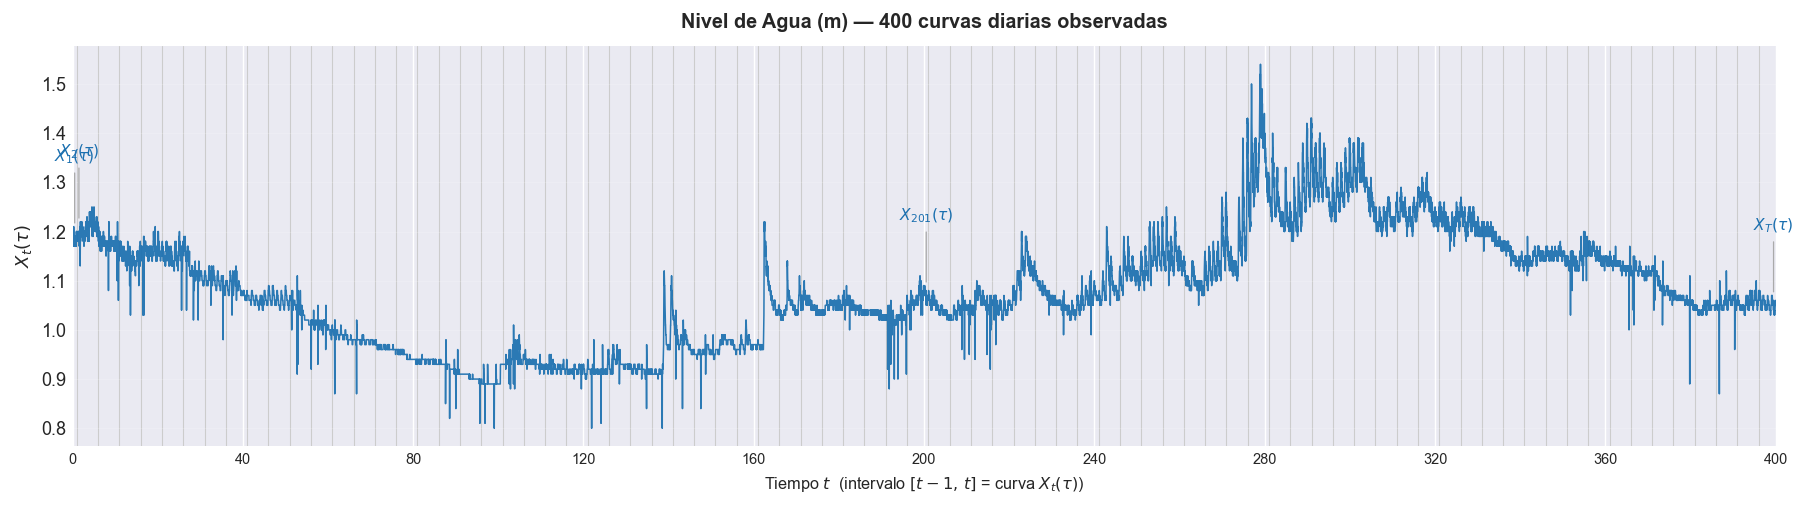

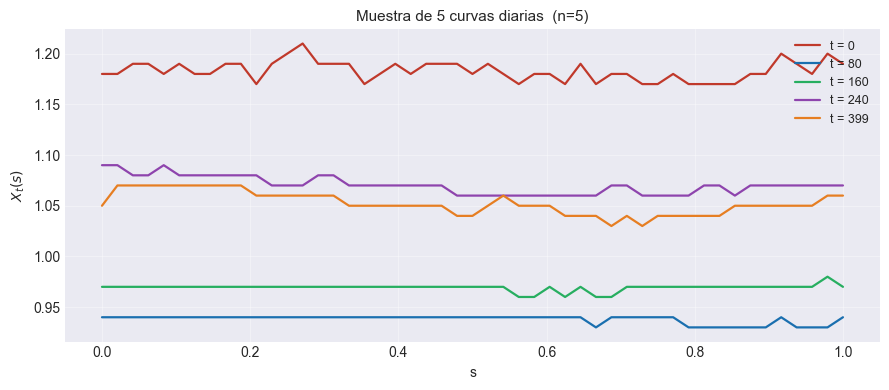

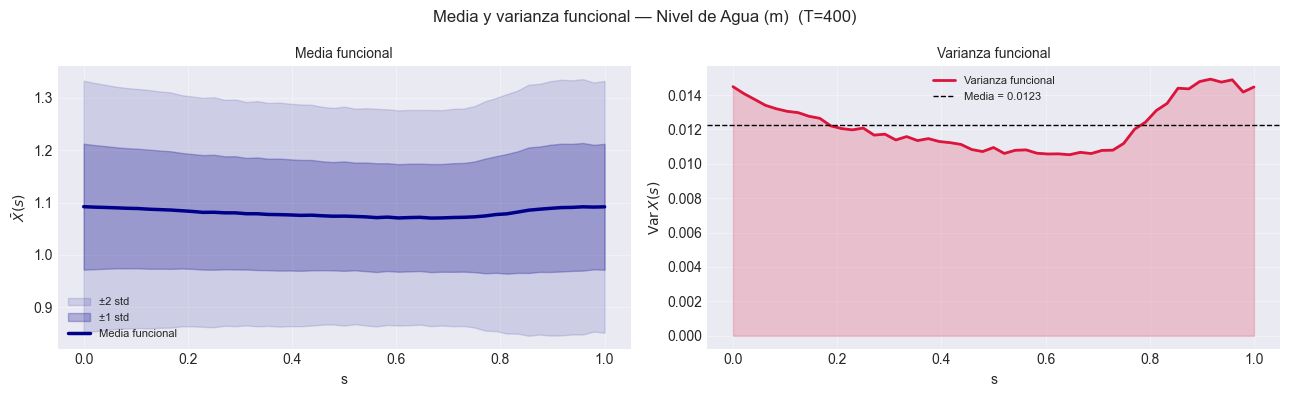

In [6]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"{VARIABLE} — {T} curvas diarias observadas",
    save_path=str(PATHS["out_report"] / "01_fts_empirica_raw.png"))
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, T // 5, 2 * T // 5, 3 * T // 5, T - 1],
    title="Muestra de 5 curvas diarias",
    save_path=str(PATHS["out_report"] / "02_muestra_empirica_raw.png"))
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title=f"Media y varianza funcional — {VARIABLE}",
    save_path=str(PATHS["out_report"] / "03_media_varianza_raw.png"))
plt.show()

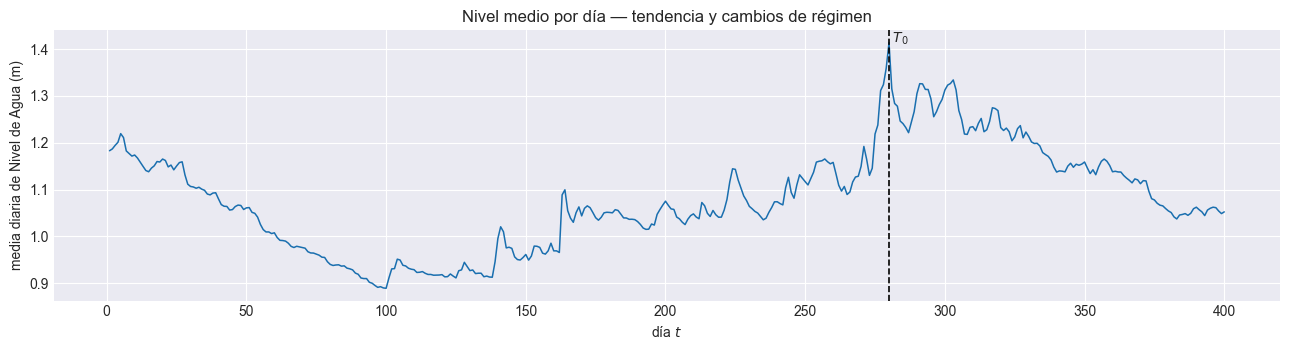

Media del nivel diario por tercio de la muestra:
  tercio 1: 1.0145  (sd 0.0982)
  tercio 2: 1.0487  (sd 0.0578)
  tercio 3: 1.1787  (sd 0.0880)

Una deriva marcada entre tercios significa que el bloque de prueba no es
una muestra de la misma ley que el de entrenamiento: hay que declararlo al
leer la caída de desempeño en T0.


In [7]:
# Nivel diario en el tiempo, con el corte train/test marcado. Es la figura que
# dice si la serie tiene tendencia o cambios de régimen: ambos rompen la
# estacionariedad que los escenarios simulados imponen por construcción, y en
# datos reales son la norma.
_T0_prev = int(np.floor(PROP_TRAIN * T))

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(np.arange(1, T + 1), _nivel, lw=1.1, color="#1a6faf")
ax.axvline(_T0_prev, color="k", ls="--", lw=1.2)
ax.text(_T0_prev, ax.get_ylim()[1], r" $T_0$", va="top", fontsize=10)
ax.set_xlabel("día $t$"); ax.set_ylabel(f"media diaria de {VARIABLE}")
ax.set_title("Nivel medio por día — tendencia y cambios de régimen")
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "04_nivel_diario.png", dpi=150,
            bbox_inches="tight")
plt.show()

print("Media del nivel diario por tercio de la muestra:")
for i, tercio in enumerate(np.array_split(_nivel, 3), 1):
    print(f"  tercio {i}: {tercio.mean():.4f}  (sd {tercio.std(ddof=1):.4f})")
print("\nUna deriva marcada entre tercios significa que el bloque de prueba no "
      "es\nuna muestra de la misma ley que el de entrenamiento: hay que "
      "declararlo al\nleer la caída de desempeño en T0.")

### 2.4 Persistencia de curvas

Sólo `X_curves.npy`: **no** hay `X_curves_true.npy` porque no hay curva sin
ruido. `cargar_curvas_true(PATHS, estricto=False)` devolverá `None` aguas
abajo, y los notebooks `_04` y `_05` toman entonces la curva observada como
objetivo de evaluación.

In [8]:
_p = guardar_curvas(PATHS, X_raw, grilla)      # sin X_true: no existe
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} → {ruta.name}")

# Análogo real de simulation_config.json. Lo lee 21_05 §3.2 para documentar la
# fuente, igual que allí se leen los parámetros del generador.
dataset_config = {
    "fuente":        str(ARCHIVO_EXCEL),
    "estacion":      "RIO MAPOCHO EN LOS ALMENDROS",
    "variable":      VARIABLE,
    "serie_id":      SERIE_ID,
    "ventana_id":    int(VENTANA_ID),
    "fecha_inicio":  str(pd.Timestamp(DIAS[0]).date()),
    "fecha_fin":     str(pd.Timestamp(DIAS[-1]).date()),
    "T": int(T), "G": int(G),
    "prop_train":    float(PROP_TRAIN),
    "ancla_continuidad": bool(ANCLA_CONTINUIDAD),
    "max_hueco_dia": float(MAX_HUECO_DIA),
    "margen_dias":   int(MARGEN_DIAS),
    "diagnostico":   diagnostico,
    "experiment_id": EXPERIMENT_ID,
    "procesado":     datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}
with open(PATHS["raw"] / "dataset_config.json", "w", encoding="utf-8") as f:
    json.dump(dataset_config, f, indent=2, ensure_ascii=False)

# Los días, para poder etiquetar cualquier figura por fecha aguas abajo.
pd.Series(DIAS, name="dia").to_csv(PATHS["raw"] / "dias.csv", index=False)
print(f"[raw] dataset_config.json · dias.csv → {PATHS['raw']}")

[functional] curvas       → X_curves.npy
[functional] grilla       → domain_grid.npy
[raw] dataset_config.json · dias.csv → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_nivel_v01_m03


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [9]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 280]      → (280, 49)
prueba        : t ∈ [281, 400]  → (120, 49)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,96.6986%,0.012639,0.084774,0.000317
1,3,2,98.3773%,0.009661,0.042792,0.000163
2,4,2,98.6470%,0.008684,0.045766,0.000142
3,5,2,98.7665%,0.008286,0.038688,0.000135
4,6,2,98.8682%,0.007982,0.033360,0.000130
5,7,2,99.0109%,0.007561,0.029201,0.000119
6,8,2,99.0804%,0.007252,0.028972,0.000116
7,9,2,99.1188%,0.007082,0.028347,0.000117
8,10,2,99.1777%,0.006872,0.028663,0.000115
9,11,2,99.1950%,0.006764,0.028964,0.000118



GCV mínimo → n_basis=10, order=2  (var retenida 99.1777%)


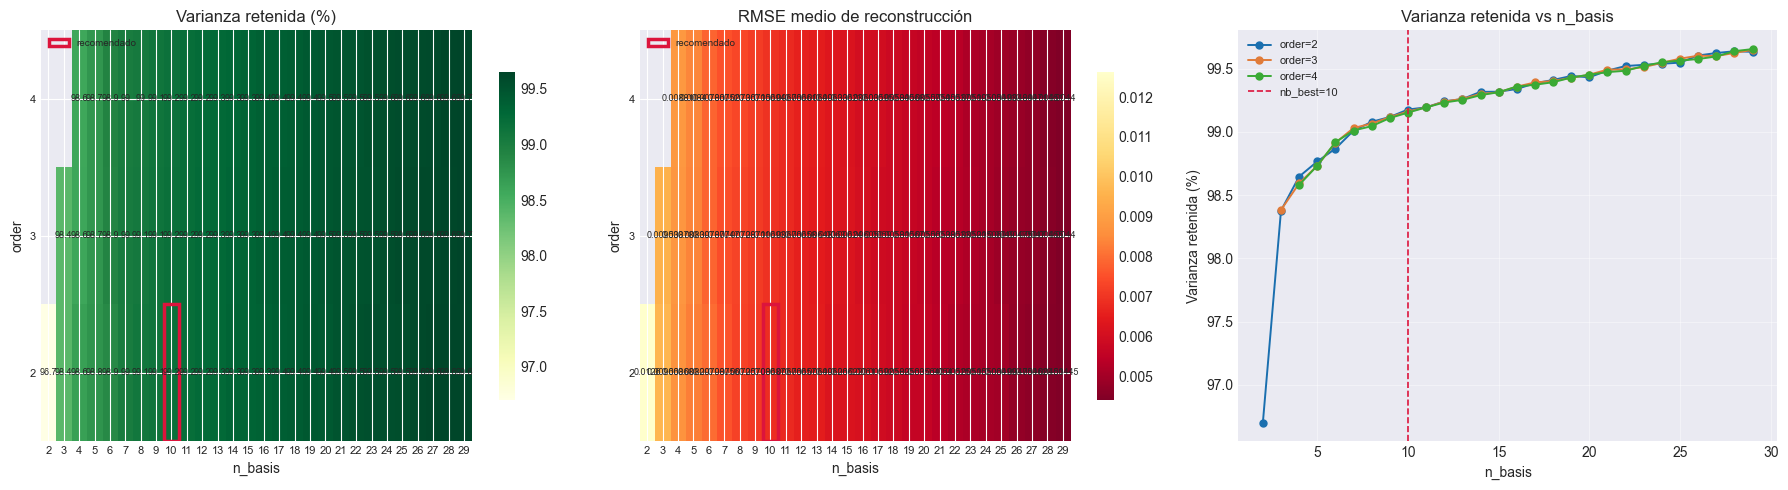

In [10]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best,
                     save_path=str(PATHS["out_report"] / "05_seleccion_basis.png"))
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=10, order=2
Sugerido GCV : n_basis=10, order=2   (coinciden)
THETA (400, 10)  (train=280, test=120)


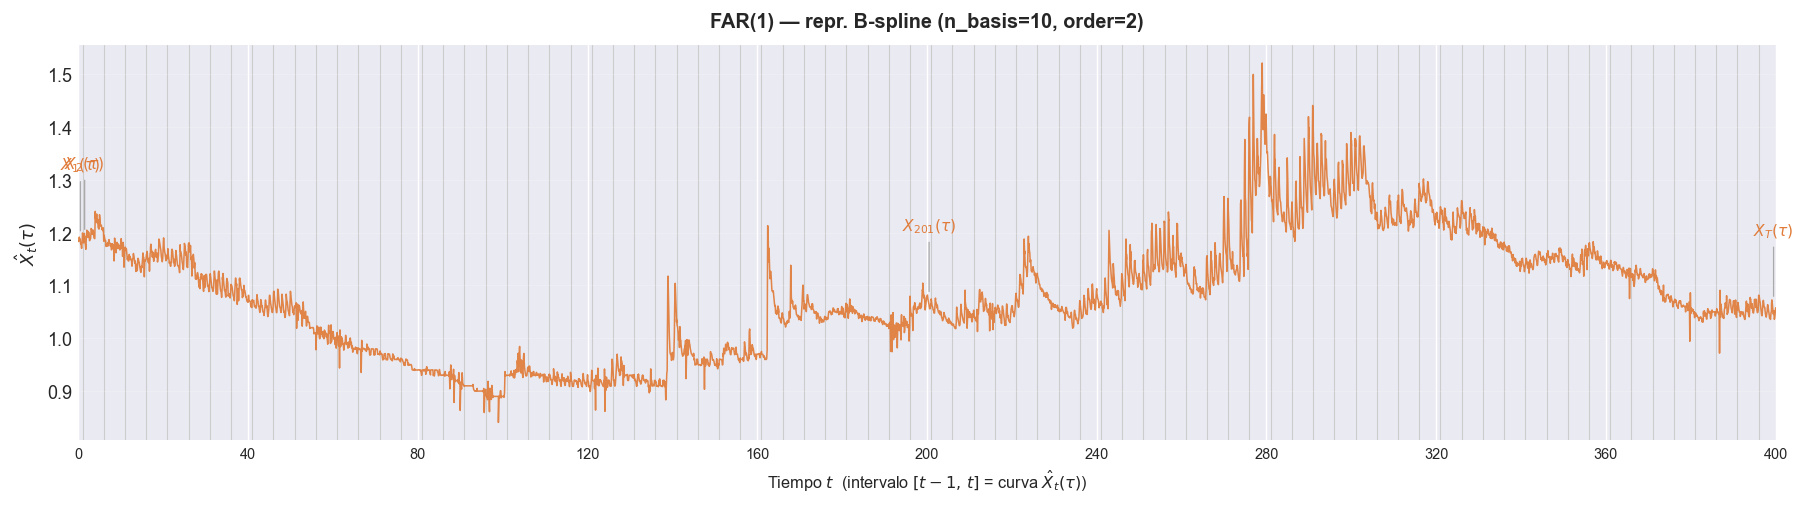

[functional] functional_representation.pkl + theta.csv + fr_config.json


In [11]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})",
    save_path=str(PATHS["out_report"] / "06_fts_funcional_bspline.png"))
plt.show()

guardar_representacion(PATHS, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print("[functional] functional_representation.pkl + theta.csv + fr_config.json")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [12]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 10
  K                                  = 10
  n_ajuste                           = 280
  cond_W                             = 3.864e+00
  err_ortonormalidad_L2              = 2.220e-15
  err_ortonormalidad_gram            = 1.998e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 6.661e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.913e-16
  err_media_scores_rel               = 6.325e-14
  err_var_scores_vs_lambda           = 3.846e-19
  err_var_scores_vs_lambda_rel       = 1.898e-13
  err_correlacion_lag0               = 2.213e-13
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok    

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,8.5062e-03,97.0928%,97.0928%,+1.011
1,2,1.4106e-04,1.6101%,98.7029%,+0.438
2,3,7.1025e-05,0.8107%,99.5136%,+0.091
3,4,1.3517e-05,0.1543%,99.6679%,+0.205
4,5,9.5205e-06,0.1087%,99.7765%,-0.059
5,6,7.3608e-06,0.0840%,99.8605%,+0.176
6,7,4.1754e-06,0.0477%,99.9082%,+0.182
7,8,3.6811e-06,0.0420%,99.9502%,-0.005
8,9,2.7252e-06,0.0311%,99.9813%,+0.178
9,10,1.6359e-06,0.0187%,100.0000%,-0.100



K disponibles: 10   ·   sugerencia (var ≥ 95%): M = 1


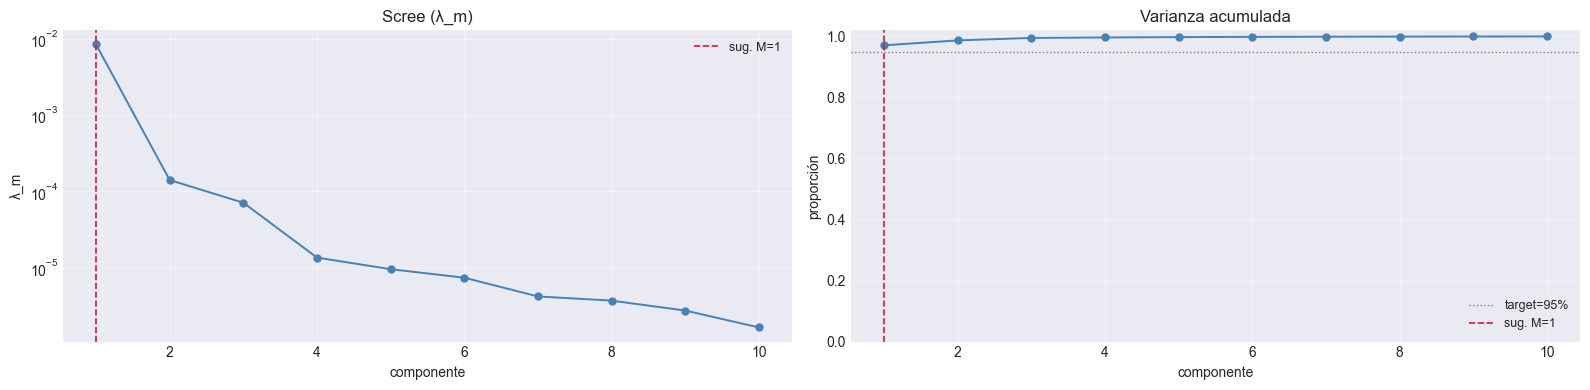

In [13]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET,
                save_path=str(PATHS["out_report"] / "07_fpca_scree.png"))
plt.show()

### 3.4 `[CONFIG]` Componentes FPCA retenidas

In [14]:
# M_FPCA se declara arriba, en la celda [CONFIG] de §1.1, porque forma parte
# del EXPERIMENT_ID y las rutas se arman antes de llegar aquí. Esta celda sólo
# lo consume y lo contrasta con la regla del 95 % (M_SUGERIDO, de §3.3).
#
# En datos reales la regla suele pedir MÁS componentes que en los
# escenarios simulados: la curva diaria observada tiene estructura fina
# que ningún generador del anexo produce, y parte de ella es ruido de
# medición. Ése es el argumento para barrer M por debajo de la regla.
assert 1 <= M_FPCA <= fpca.evals.size, f"M_FPCA fuera de [1, {fpca.evals.size}]."

print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
print(f"M_FPCA de esta corrida : {M_FPCA}"
      + ("   (coincide con la regla)" if M_FPCA == M_SUGERIDO
         else "   ← DIFIERE de la regla: es un punto del barrido"))
fpca.set_M(int(M_FPCA))
M_fpca = fpca.M

Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
print(f"[train] max|media ξ| = {np.abs(SCORES_train.mean(0)).max():.2e}   (≈ 0)")
print(f"[test]  max|media ξ| = {np.abs(SCORES_test.mean(0)).max():.3f}")
print(f"[test]  var ξ / λ    = "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

M(95 %) según la regla : 1   (K disponible = 10)
M_FPCA de esta corrida : 3   ← DIFIERE de la regla: es un punto del barrido
M = 3   var. explicada = 99.5136%
[train] max|media ξ| = 2.91e-16   (≈ 0)
[test]  max|media ξ| = 0.133
[test]  var ξ / λ    = [0.87  0.818 0.434]


## 4. Datasets AR($p$) sobre los scores

### 4.1 Estandarización

El estandarizador se ajusta **sólo con train** y registra `n_ajuste` para que
esa disciplina sea auditable desde el artefacto y no una promesa del notebook.

[holdout] ajustado con 280 filas = T0 (train[1:280]) → ok=True

SCORES_STD (400, 3)
  [train] max|media| = 1.14e-16  (≈0)
  [train] max|std-1| = 2.22e-16  (≈0)
  [test]  media = [ 1.448 -0.49   0.191]
  [test]  std   = [0.931 0.903 0.657]

[functional] artefactos FPCA · cond_W = 3.864e+00


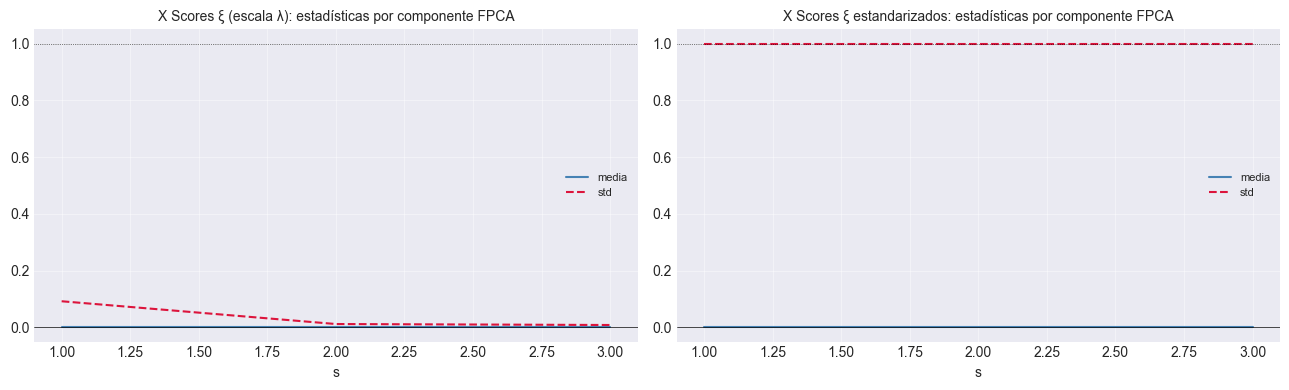

In [15]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

_chk = scores_standardizer.verificar_ajuste(T0)
print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
      f"({_chk['etiqueta_ajuste']}) → ok={_chk['ajuste_ok']}")

SCORES_STD       = scores_standardizer.transform(SCORES)
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(f"\nSCORES_STD {SCORES_STD.shape}")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (≈0)")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (≈0)")
print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

guardar_estandarizador(PATHS, scores_standardizer)
_res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                    meta_extra={"T0": int(T0)})
print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
plt.show()

### 4.2 Diagnóstico de rezagos (sólo train)

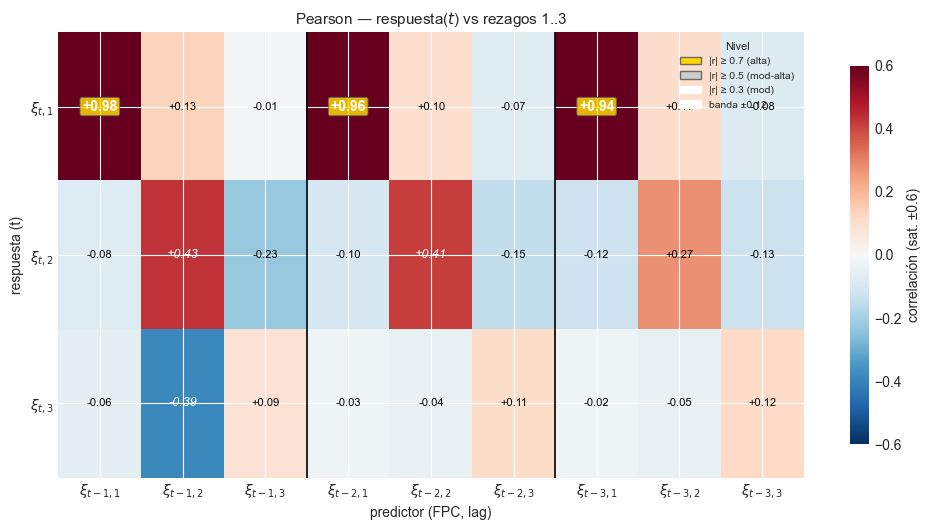

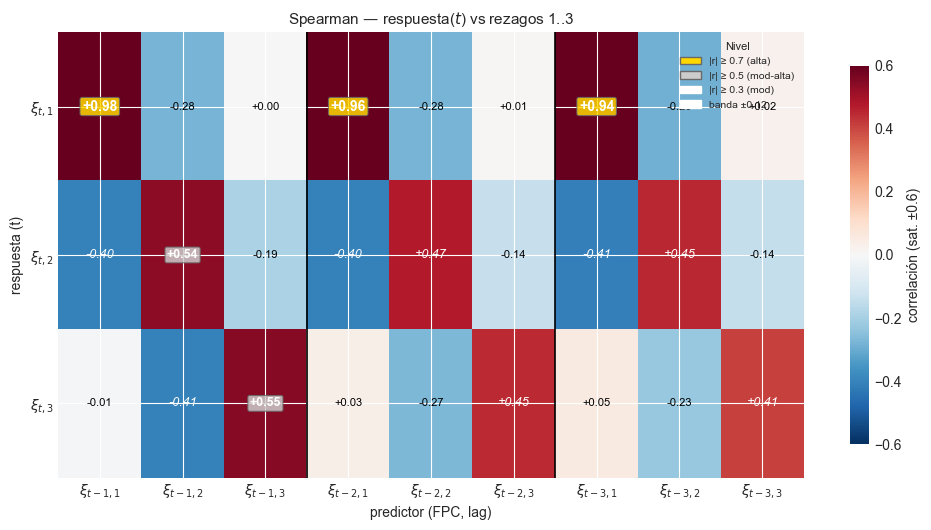

In [16]:
N_LAGS_MAX = 3
T_theta, K_total = SCORES_STD_train.shape

def _spearman(Y, Xm):
    """Spearman columna a columna vía rangos (pandas, sin scipy)."""
    Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
    Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
corr_s = np.zeros_like(corr_p)
col_labels = []
y_block = SCORES_STD_train[N_LAGS_MAX:, :]

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
    sp = _spearman(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_s[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band = 1.96 / np.sqrt(len(y_block))

for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
    plot_rezagos_heatmap(
        M_corr, col_labels, row_labels,
        title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}",
        n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
        save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
    plt.show()

### 4.3 `[CONFIG]` Orden AR y construcción de los datasets

Los rezagos del primer origen de prueba vienen del final del bloque de
entrenamiento: son observaciones pasadas disponibles en cada origen, de modo
que su uso es el condicionamiento de la predicción a $h=1$, no fuga.

In [17]:
N_LAGS        = 1
COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

n_components = len(COMPONENT_IDX)
n_train_eff  = T0 - N_LAGS
n_test_eff   = T - T0

assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
             for lag in range(1, N_LAGS + 1)
             for j in range(n_components)]

print(f"componentes : {n_components} → índices {COMPONENT_IDX}")
print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
print(f"cov_names   : {cov_names}")

componentes : 3 → índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariables
n_train_eff : 279   n_test_eff : 120
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']


In [18]:
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

def _dataset_bloque(k, t_ini, t_fin):
    """Respuesta en t ∈ [t_ini, t_fin) y predictores en t-1 … t-N_LAGS."""
    t_idx  = np.arange(t_ini, t_fin)
    X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
    "ajuste_en": "train",
}
guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
for k in range(n_components):
    print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (279, 4) · test (120, 4)
  fpc_2: train (279, 4) · test (120, 4)
  fpc_3: train (279, 4) · test (120, 4)


## 5. `[CONFIG]` Hiperparámetros y configuración MCMC

Esto es el **contrato con MATLAB**: `psbp_fd_iteracion.m` lee estos valores del
JSON y no los tiene escritos a mano, incluida `seed_base`.

Ojo con la doble acepción de `M`: aquí, dentro de `mcmc_config`, es el tamaño
de la grilla de localización $G^*$ del stick-breaking, **no** el número de
componentes FPCA. `N` es el truncamiento del número de átomos.

In [19]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 35, "M": 35}
N_CHAINS    = 3

print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS} cadenas por componente "
      f"→ {N_CHAINS * n_components} jobs en MATLAB")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) × {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 35, 'M': 35}
N_CHAINS    : 3 cadenas por componente → 9 jobs en MATLAB
Draws posteriores por score: (2000 - 500) × 3 = 4500


In [20]:
# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

def _clasificar(nombre, k_modelo):
    return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
            else "cross_lag")

HYPERPARAMS_LIST = []
for k in range(n_components):
    tipos = [_clasificar(nm, k) for nm in cov_names]
    vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
    HYPERPARAMS_LIST.append({**HP_GLOBAL,
        "apij": vals[:, 0], "bpij": vals[:, 1],
        "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
    for j, nm in enumerate(cov_names):
        a, b = hp["apij"][j], hp["bpij"][j]
        marca = "  ◄" if _clasificar(nm, k) == "own_lag1" else ""
        print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
              f"{a/(a+b):>7.3f}{marca}")


Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=2  (fpc_3)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             own_lag1       9.0    1.0   0.900  ◄


In [21]:
hp_artifact = {
    "global":       HP_GLOBAL,
    "by_type":      HP_BY_TYPE,
    "mcmc_config":  MCMC_CONFIG,
    "n_iter":       N_CHAINS,
    "seed_scheme":  "seed_base + chain*9973 + k*31",
    "serie_id":     SERIE_ID,
    "ventana_id":   int(VENTANA_ID),
    "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
    "scores_scale": "standardized_zscore_ddof0",
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": [
        {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
         "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                         for key, v in HYPERPARAMS_LIST[k].items()}}
        for k in range(n_components)
    ],
}
guardar_hiperparametros(PATHS, hp_artifact)
print(f"✓ hyperparameters.json → {PATHS['out_artefact']}")

✓ hyperparameters.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_nivel_v01_m03


## 6. Configuración de evaluación, líneas base y verificación del contrato

`objetivo_evaluacion` y `modo_residuo` se declaran aquí porque cambian el
significado de toda la evaluación y no deben quedar como una decisión implícita
del notebook `_04`.

In [22]:
eval_config = {
    "scheme":      "holdout_temporal",
    "fuente":      "datos observados (estación hidrológica)",
    "variable":    VARIABLE,
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "horizons":    [1],
    "n_lags":      int(N_LAGS),
    "scores_scale": "standardized_zscore_ddof0",
    # Contra QUÉ se mide el error y con qué banda. Declarado explícitamente:
    #   En datos reales no existe la curva sin ruido, de modo que el objetivo es
    #   la curva OBSERVADA. Con ese objetivo el residuo de representación NO es
    #   opcional: la banda tiene que cubrir también lo que las M autofunciones
    #   no representan, y con modo_residuo="ninguno" aparecería subcobertura
    #   atribuible a la representación y no al modelo.
    #   Consecuencia al reportar: estas cifras incluyen el ruido de medición,
    #   que ningún modelo puede predecir, y NO son comparables con las de los
    #   escenarios simulados, medidas contra X_t(tau).
    "objetivo_evaluacion": "curva_observada",
    "modo_residuo":        "empirico",
    "nivel_credibilidad":  0.95,
    "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
    "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
    "metrics_curvas": ["MISE", "RMSE_funcional"],
    "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
}
guardar_config_evaluacion(PATHS, eval_config)
print("[out_artefact] eval_config.json")
for k, v in eval_config.items():
    print(f"  {k:22s}: {v}")

[out_artefact] eval_config.json
  scheme                : holdout_temporal
  fuente                : datos observados (estación hidrológica)
  variable              : Nivel de Agua (m)
  T                     : 400
  T0                    : 280
  prop_train            : 0.7
  horizons              : [1]
  n_lags                : 1
  scores_scale          : standardized_zscore_ddof0
  objetivo_evaluacion   : curva_observada
  modo_residuo          : empirico
  nivel_credibilidad    : 0.95
  ventana_movil         : {'w': [10, 20, 40], 'paso': 1, 'solapadas': True}
  metrics_scores        : ['RMSE', 'R2', 'razon_dispersion']
  metrics_curvas        : ['MISE', 'RMSE_funcional']
  metrics_dist          : ['CRPS', 'energy_score', 'cobertura_95', 'PIT']


In [23]:
# Líneas base a h=1: el piso que el PSBP-FD debe superar.
baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                               fpca=fpca, X_obs=X_raw, tau=grilla, h=1)
baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
display(baselines_df.style.format("{:.4f}", na_rep="—")
        .set_caption("Líneas base — bloque de prueba, h=1, contra la curva OBSERVADA"))

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,120.0000,1.7209,1.0268,0.6842,1.1440,-0.9329,0.0254,0.1593
persistencia_lag1,120.0000,0.1763,0.9616,0.4877,0.5419,0.4260,0.0005,0.0226


In [24]:
informe = verificar_contrato(PATHS)
print(f"contrato_ok = {informe['contrato_ok']}   "
      f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
      f"n_components={informe['n_components']})")
print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas (T0={informe['T0']})")
print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
if not informe["contrato_ok"]:
    print("\nPROBLEMAS:")
    for p in informe.get("problemas", []):
        print(f"  - {p}")

print(f"\n{'='*66}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"EXPERIMENT_ID = {EXPERIMENT_ID}   (M_FPCA={M_FPCA})\n{'='*66}")

contrato_ok = True   (M=3, K=10, T0=280, n_components=3)
estandarizador ajustado con 280 filas (T0=280)
verificación FPCA: todo_ok = True

Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
EXPERIMENT_ID = real_nivel_v01_m03   (M_FPCA=3)
